# 16b · Optimizer Solver Comparison — SLSQP vs "MINLP-style" vs GA

**ทำไมมี notebook นี้:** `16_cleaning_plan_optimization.ipynb` / `cleaning_scheduler_network.py`
แก้ปัญหาการเลือกล้าง online (`y[hx,t] ∈ {0,1}`) ด้วย **SLSQP บน continuous relaxation แล้ว round** —
เร็วและมี track record ที่ตรวจสอบแล้ว (v1-vs-v2 comparison, feasibility asserts) แต่มันคือ relaxation
ไม่ใช่ exact solver สำหรับปัญหา integer จริง การ round จุด optimum ต่อเนื่อง **ไม่รับประกัน** ว่าจะได้
optimum ของปัญหา integer

Notebook นี้แก้ปัญหา window เดียวกันทุกประการ (objective/constraint เดียวกับ production) ด้วย
**อีก 2 วิธีที่ไม่พึ่ง continuous relaxation + rounding**:

1. **"MINLP-style" global solver**: `scipy.optimize.differential_evolution(integrality=True)` —
   mixed-integer nonlinear global optimizer ที่มากับ scipy อยู่แล้ว (ไม่ต้องติดตั้งอะไรเพิ่ม)
   *ไม่ใช่* Pyomo + Bonmin/Couenne (MINLP solver เต็มรูปที่มี optimality-gap certificate) ซึ่งจะเป็นการ
   ติดตั้งหนักและเสี่ยงพังบน environment นี้ สำหรับโปรเจกต์ที่ตั้งใจคุม dependency ให้เบา
   (ดู `requirements-full.txt`) — นี่คือทางเลือกที่ปฏิบัติได้จริง: mixed-integer global search แท้ๆ
   เพียงแต่ไม่มี certified optimality gap
2. **Genetic Algorithm**: GA เล็กๆ ไม่มี dependency เพิ่ม (binary chromosome = `y[hx,t]` แบบ flatten,
   tournament selection, uniform crossover, bit-flip mutation, elitism, constraint จัดการด้วย penalty)

ทั้งสามวิธีถูกวัดบน **objective เดียวกันทุกบาท** (`window_objective`, THB) ที่ SLSQP ใช้อยู่แล้ว
เทียบกันได้ตรงๆ — ไม่ใช่ apples-to-oranges

**คำแนะนำเชิงปฏิบัติ:** ผลจาก notebook นี้ใช้เป็น**การตรวจสอบเป็นระยะ (offline)** ไม่ใช่ production step —
DE/GA ช้ากว่า SLSQP มาก (ดูตัวเลขเวลาด้านล่าง) ไม่เหมาะรันทุกครั้งที่กดปุ่ม "คำนวณใหม่" บนแดชบอร์ด
ถ้าผลต่างกันไม่มาก (`<2-3%`) แปลว่า SLSQP+round เพียงพอแล้ว ไม่ต้องเปลี่ยน production solver

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(REPO / 'pipeline'))
import cleaning_scheduler_network as NS
import solver_comparison as SC

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

## 1 · โหลดปัญหาเดียวกับ production

ใช้ input ชุดเดียวกับที่ `16_cleaning_plan_optimization.ipynb` / `pipeline/run_all.py` ใช้จริง
(`economics.json`, `cleaning_history.json`, `cleaning_logistics.json`) เพื่อให้การเปรียบเทียบสมจริง
ไม่ใช่ปัญหาสังเคราะห์

In [2]:
econ = NS._load('economics.json', {})
chist = NS._load('cleaning_history.json', {'hx': {}})
logi = NS._load('cleaning_logistics.json', {'hx': []})

pc = econ.get('plant_constants', {})
feed_kbd = econ.get('feed_kbd') or 79.3
k_per_day = pc.get('STD_ENERGY', 0.74) * feed_kbd * pc.get('NG_PRICE', 390)

state = NS.build_hx_state(econ, chist, logi)
online_ids = sorted([hx for hx, s in state.items() if s['online'] and s['r'] >= NS.MIN_RATE])
r = np.array([state[hx]['r'] for hx in online_ids])
cost = np.array([state[hx]['cost'] for hx in online_ids])
dev0 = np.array([state[hx]['deviation0'] for hx in online_ids])

print(f'{len(online_ids)} online-capable HX: {online_ids}')
print(f'crew cap (ASSUMED, รอวิศวกร): {NS.MAX_ONLINE_CLEANS_PER_PERIOD}/period')
print(f'k = {k_per_day:,.0f} THB/day per degC of network CIT deficit')

8 online-capable HX: ['E101AB', 'E101CD', 'E102', 'E104', 'E105AB', 'E108AB', 'E110ABC', 'E113A']
crew cap (ASSUMED, รอวิศวกร): 2/period
k = 23,030 THB/day per degC of network CIT deficit


## 2 · เทียบ 3 solver บนหน้าต่างเดียวกัน หลายขนาด

ขนาดหน้าต่าง (2/4/6 เดือน) ตรงกับ `WINDOW_CANDIDATES` sweep ที่ production กวาดหาอยู่แล้ว
(`cleaning_scheduler_network.py`) — เป็นหน่วยจริงที่ SLSQP ต้องแก้ทุก step ของ moving-window schedule
ไม่ใช่การแก้ทั้ง horizon รวดเดียว (ซึ่งเป็นปัญหาคนละแบบ ใหญ่กว่ามาก และไม่ใช่สิ่งที่ production ทำ)

In [3]:
all_rows = []
for n_t in (2, 4, 6):
    rows, _ = SC.compare_one_window(dev0, r, cost, k_per_day, n_t, NS.MAX_ONLINE_CLEANS_PER_PERIOD)
    for row in rows:
        row['window_months'] = n_t
    all_rows.extend(rows)

cmp_df = pd.DataFrame(all_rows)[['window_months', 'solver', 'objective_thb', 'solve_s', 'n_cleans', 'pct_above_best']]
cmp_df

,window_months,solver,objective_thb,solve_s,n_cleans,pct_above_best
0,2,slsqp_rounded,15196743,0.084,4,0.00
1,2,de_minlp_style,15196743,9.498,4,0.00
2,2,ga,15196743,1.451,4,0.00
3,4,slsqp_rounded,23243188,0.119,8,3.19
4,4,de_minlp_style,22525276,27.373,8,0.00
5,4,ga,23243188,1.658,8,3.19
6,6,slsqp_rounded,30035033,0.195,12,0.00
7,6,de_minlp_style,33355891,34.082,12,11.06
8,6,ga,31917652,1.810,12,6.27


## 3 · อ่านผลอย่างตรงไปตรงมา

`pct_above_best` = ส่วนต่างจาก solver ที่ดีที่สุดในหน้าต่างนั้น (0% = ชนะ/เสมอ) — **ไม่ได้ตั้งเป้าให้ SLSQP ชนะเสมอ**
ถ้า DE/GA เจอคำตอบที่ดีกว่าจริง จะรายงานตรงตามนั้น (เช่นเดียวกับหลักการ v1-vs-v2 comparison ใน notebook 16)

In [4]:
best_by_window = cmp_df.loc[cmp_df.groupby('window_months')['objective_thb'].idxmin()]
print('best solver per window size:')
print(best_by_window[['window_months', 'solver', 'objective_thb', 'solve_s']].to_string(index=False))

max_gap = cmp_df[cmp_df['solver'] == 'slsqp_rounded']['pct_above_best'].max()
print(f'\nSLSQP worst-case gap vs best solver found: {max_gap:.2f}%')
if max_gap < 3.0:
    print('-> SLSQP+round is within the "close enough" threshold (<3%) suggested by the plan --')
    print('   no need to change the production solver based on this run.')
else:
    print('-> SLSQP+round left a non-trivial gap on at least one window size. Worth investigating')
    print('   whether DE/GA solve time is acceptable to run periodically (NOT live on every dashboard')
    print('   "คำนวณใหม่" click -- see the timing numbers above) as a supplementary check.')

best solver per window size:
 window_months         solver  objective_thb  solve_s
             2  slsqp_rounded       15196743    0.084
             4 de_minlp_style       22525276   27.373
             6  slsqp_rounded       30035033    0.195

SLSQP worst-case gap vs best solver found: 3.19%
-> SLSQP+round left a non-trivial gap on at least one window size. Worth investigating
   whether DE/GA solve time is acceptable to run periodically (NOT live on every dashboard
   "คำนวณใหม่" click -- see the timing numbers above) as a supplementary check.


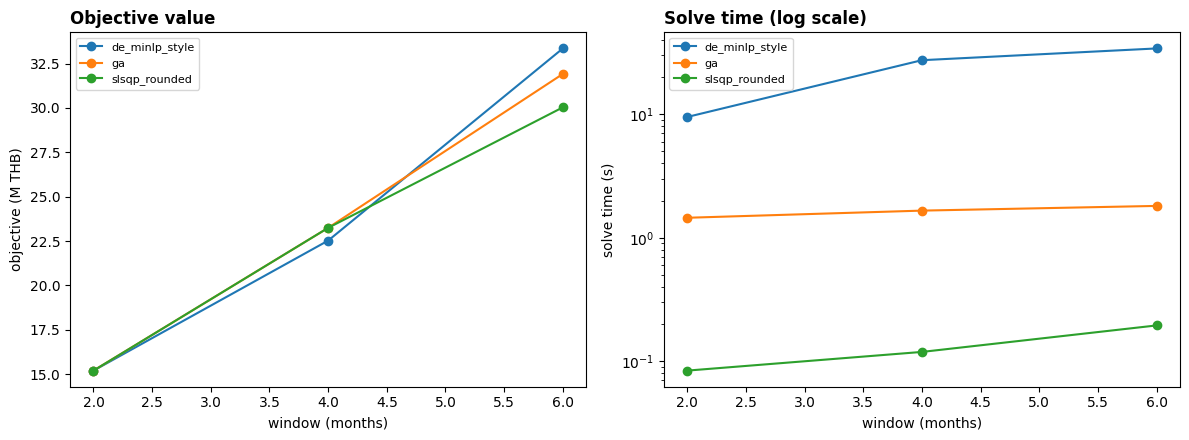

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for solver, g in cmp_df.groupby('solver'):
    ax1.plot(g['window_months'], g['objective_thb'] / 1e6, marker='o', label=solver)
    ax2.plot(g['window_months'], g['solve_s'], marker='o', label=solver)
ax1.set_xlabel('window (months)'); ax1.set_ylabel('objective (M THB)'); ax1.set_title('Objective value', loc='left', fontweight='bold')
ax2.set_xlabel('window (months)'); ax2.set_ylabel('solve time (s)'); ax2.set_yscale('log')
ax2.set_title('Solve time (log scale)', loc='left', fontweight='bold')
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'fig_solver_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## 4 · ข้อจำกัด (limitations)

- **DE/GA เป็น stochastic search** — ผลอาจเปลี่ยนได้ถ้าเปลี่ยน `seed`; ตัวเลขในโน้ตบุ๊กนี้คือ 1 run
  ต่อ solver ต่อขนาดหน้าต่าง ไม่ใช่ค่าเฉลี่ยจากหลาย seed (ถ้าจะใช้ผลนี้ตัดสินใจเปลี่ยน production solver
  จริงจัง ควรรันซ้ำหลาย seed ก่อน)
- **DE ไม่ได้มี optimality-gap certificate** เหมือน MINLP solver เต็มรูป (Bonmin/Couenne/SCIP ผ่าน Pyomo) —
  เป็น global search ที่ดี ไม่ใช่ exact solver ที่พิสูจน์ได้ว่าเจอ optimum จริง
- **ยิ่งหน้าต่างใหญ่ (ตัวแปรมากขึ้น) DE/GA ยิ่งต้องการ iteration/population มากขึ้น** เพื่อคุณภาพเท่าเดิม —
  ถ้าเห็น DE/GA แพ้ SLSQP ที่หน้าต่างใหญ่ อาจเป็นเพราะ budget (`maxiter`/`popsize`/`n_generations`) ไม่พอ
  ไม่ใช่ว่า SLSQP เก่งกว่าเชิงโครงสร้าง — ปรับ budget ใน `pipeline/solver_comparison.py` แล้วรันซ้ำถ้าสงสัย
- **เปรียบเทียบที่ระดับหน้าต่างเดียว ไม่ใช่ทั้ง horizon multi-TAM** — การรัน DE/GA ทุก step ของ
  moving-window schedule เต็ม horizon (24-70+ periods, ดู notebook 16) จะช้าเกินไปสำหรับ offline check
  นี้; ถ้าต้องการเทียบทั้ง horizon จริงๆ ต้องรัน `run_schedule()` แบบ custom solver ทุก step ซึ่งเป็นงานเพิ่ม
  ที่ไม่ได้ทำใน notebook นี้